<a href="https://colab.research.google.com/github/EzinneUfondu/python_new/blob/main/ML_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load your Dataset

In [ ]:
import pandas as pd

df=pd.read_csv('/Data_Feb_2026.csv')

print(df.shape)
print(df.head())
print(df.dtypes)

(1375, 5)
        X1      X2      X3       X4  Label
0  3.62160  8.6661 -2.8073 -0.44699    0.0
1  4.54590  8.1674 -2.4586 -1.46210    0.0
2  3.86600 -2.6383  1.9242  0.10645    0.0
3  3.45660  9.5228 -4.0112 -3.59440    0.0
4  0.32924 -4.4552  4.5718 -0.98880    0.0
X1       float64
X2       float64
X3       float64
X4       float64
Label    float64
dtype: object


#### Check for Missing Values

In [ ]:
df.isnull().sum()

,0
X1,0
X2,0
X3,0
X4,0
Label,1


##### Check for Duplicate Rows

In [ ]:
df.duplicated().sum()

np.int64(25)

#### Descriptive Statistics

In [ ]:
df.describe()

,X1,X2,X3,X4,Label
count,1375.000000,1375.000000,1375.000000,1375.000000,1374.000000
mean,0.386657,2.014202,1.359162,-1.250522,0.443959
std,3.418977,6.676094,4.527056,2.987968,0.497030
min,-70.000000,-13.773100,-50.000000,-80.000000,0.000000
25%,-1.774700,-1.697850,-1.630450,-2.428000,0.000000
50%,0.496650,2.325900,0.616630,-0.586650,0.000000
75%,2.822050,6.819300,3.181600,0.394810,1.000000
max,6.824800,120.000000,17.927400,2.449500,1.000000


#### Label Column Integrity Check

In [ ]:
print(df['Label'].unique())
print(df['Label'].value_counts())

[ 0. nan  1.]
Label
0.0    764
1.0    610
Name: count, dtype: int64


In [ ]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 25


### Drop duplicate rows

In [ ]:
df = df.drop_duplicates()
df.shape

(1350, 5)

### Drop the row with missing label

In [ ]:
df = df.dropna(subset=["Label"])
df.shape

(1349, 5)

In [ ]:
print(f"Remaining missing values: {df.isnull().sum().sum()}")
print(f"Remaining duplicates: {df.duplicated().sum()}")

Remaining missing values: 0
Remaining duplicates: 0


### Lets detect outliers using the IQR Method

In [ ]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ((df < lower_bound) | (df > upper_bound))
print("Outliers per column:")
print(outliers.sum())

Outliers per column:
X1        1
X2        1
X3       61
X4       33
Label     0
dtype: int64


#### Lets remove the outliers

In [ ]:
# Create a mask of rows that are not outliers
mask = ~((df < lower_bound) | (df > upper_bound)).any(axis=1)

# Apply the mask
df = df[mask]

print(f"Shape after removing outliers: {df.shape}")
print(f"Rows removed: {1349 - df.shape[0]}")

Shape after removing outliers: (1256, 5)
Rows removed: 93


### Exploratory Data Analysis

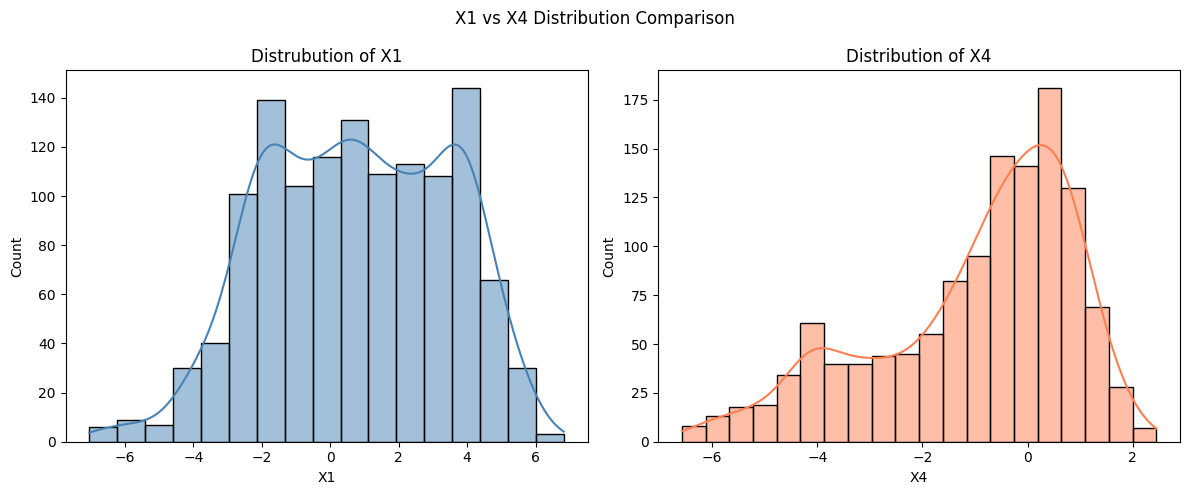

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distrubution plots for X1 and X4
fig, axes = plt.subplots(1,2, figsize=(12, 5))

sns.histplot(df['X1'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distrubution of X1')

sns.histplot(df['X4'], kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribution of X4')

plt.suptitle('X1 vs X4 Distribution Comparison')
plt.tight_layout()
plt.show()

### Statistical Summary of X1 and X4

In [ ]:
print("X1 Statistics:")
print(df['X1'].describe())
print(f"Skewness: {df['X1'].skew():.4f}")

print("\nX4 Statistics:")
print(df['X4'].describe())
print(f"Skewness: {df['X4'].skew():.4f}")

X1 Statistics:
count    1256.000000
mean        0.760507
std         2.683185
min        -7.042100
25%        -1.438950
50%         0.758160
75%         3.072000
max         6.824800
Name: X1, dtype: float64
Skewness: -0.1639

X4 Statistics:
count    1256.000000
mean       -1.001374
std         1.904462
min        -6.577500
25%        -2.114125
50%        -0.470270
75%         0.446530
max         2.449500
Name: X4, dtype: float64
Skewness: -0.8371


### Calculating Class Probablity

In [ ]:
# Counting each of the class
class_counts = df['Label'].value_counts().sort_index()
total = len(df)

# Calculating probabilities
p0 = class_counts[0.0] / total
p1 = class_counts[1.0] / total

print(f"Class counts:\n{class_counts}")
print(f"\nTotal rows: {total}")
print(f"P(Class 0) = {p0:.4f}")
print(f"P(Class 1) = {p1:.4f}")
print(f"Sum of probabilities: {p0 + p1:.4f}")

Class counts:
Label
0.0    723
1.0    533
Name: count, dtype: int64

Total rows: 1256
P(Class 0) = 0.5756
P(Class 1) = 0.4244
Sum of probabilities: 1.0000


### Gini Impurity and Entropy

In [ ]:
import numpy as np

# Gini Impurity
gini = 1 - (p0**2 + p1**2)
print(f"Gini Impurity = {gini:.4f}")

# Entropy
entropy = -(p0 * np.log2(p0) + p1 * np.log2(p1))
print(f"Entropy = {entropy:.4f}")

Gini Impurity = 0.4886
Entropy = 0.9834


### Predicting the Miscalculation Rate

In [ ]:
# Misclassification Rate

misclassification_rate = 1 - max(p0, p1)
print(f"Misclassification Rate = {misclassification_rate:.4f}")
print(f"As percentage = {misclassification_rate * 100:.2f}%")

Misclassification Rate = 0.4244
As percentage = 42.44%


# Regression  Modelling

In [ ]:
file_id2 = "1wJj-Cy5f5KmVEmD8KQH6ncup2JHNGSxn"
url2 = f"https://drive.google.com/uc?id={file_id2}"

df2 = pd.read_csv(url2)

print(df2.shape)
print(df2.head())
print(df2.dtypes)

(1000, 2)
          t         f(t)
0  0.479155     0.472010
1 -1.021461    37.567432
2 -4.467154  1507.309054
3  1.130598     5.036163
4 -1.007833    36.566910
t       float64
f(t)    float64
dtype: object


### Visualising and Plotting the Data

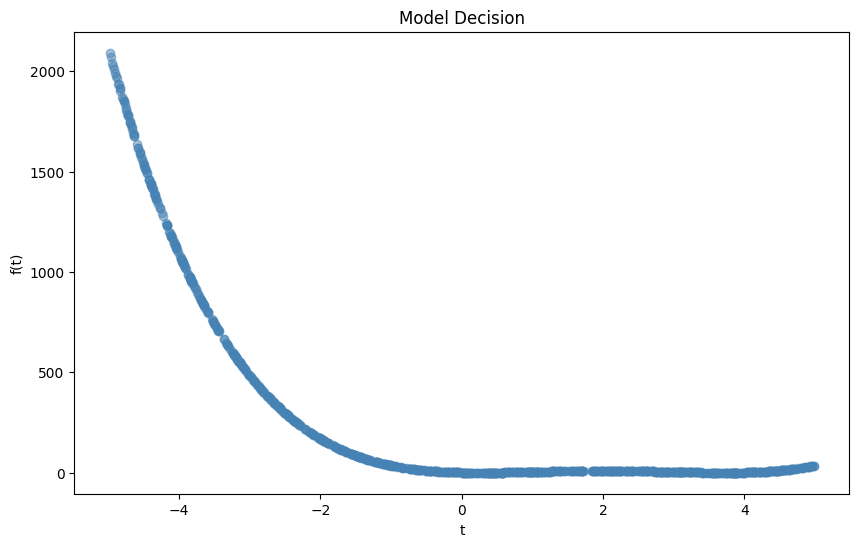

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(df2['t'], df2['f(t)'], alpha=0.5, color='steelblue')
plt.xlabel('t')
plt.ylabel('f(t)')
plt.title('Model Decision')
plt.show()

### Fitting the Exponential Regression Model

In [ ]:
from scipy.optimize import curve_fit
import numpy as np

# Defining exponential function
def exp_func(t, a, b):
    return a * np.exp(b * t)

# Fitting the model
popt, pcov = curve_fit(exp_func, df2['t'], df2['f(t)'], p0=[1, -1], maxfev=10000)

a, b = popt
print(f"Fitted parameter a = {a:.4f}")
print(f"Fitted parameter b = {b:.4f}")
print(f"Model: f(t) = {a:.4f} × np.exp({b:.4f} × t)")

Fitted parameter a = 44.3999
Fitted parameter b = -0.7868
Model: f(t) = 44.3999 × np.exp(-0.7868 × t)


### Evaluating our model

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

# Generating predictions
y_pred = exp_func(df2['t'], a, b)

# Calculating R2 and RMSE
r2 = r2_score(df2['f(t)'], y_pred)
rmse = np.sqrt(mean_squared_error(df2['f(t)'], y_pred))

print(f"R2 Score = {r2:.4f}")
print(f"RMSE = {rmse:.4f}")

R2 Score = 0.9946
RMSE = 35.9874


### Plotting the Fitted Model

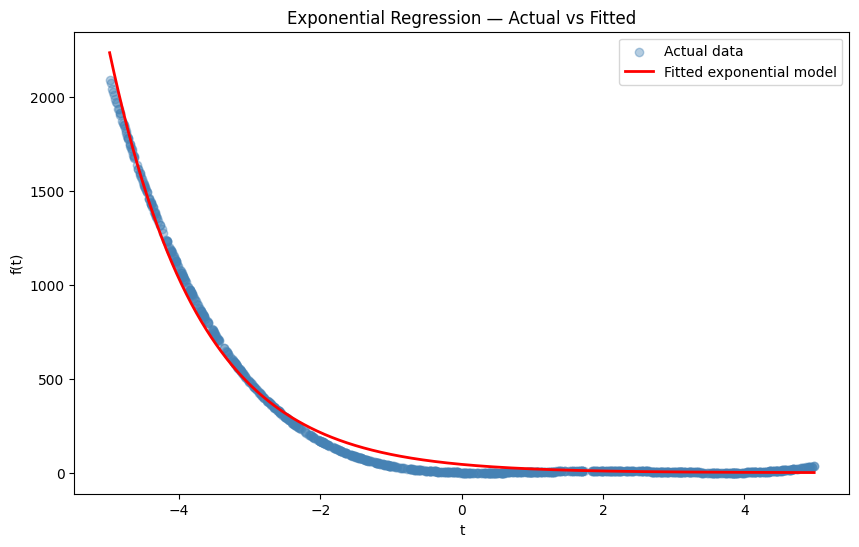

In [ ]:
# Sort values for smooth curve
t_sorted = np.linspace(df2['t'].min(), df2['t'].max(), 1000)
f_fitted = exp_func(t_sorted, a, b)

plt.figure(figsize=(10, 6))
plt.scatter(df2['t'], df2['f(t)'], alpha=0.4, color='steelblue', label='Actual data')
plt.plot(t_sorted, f_fitted, color='red', linewidth=2, label='Fitted exponential model')
plt.xlabel('t')
plt.ylabel('f(t)')
plt.title('Exponential Regression — Actual vs Fitted')
plt.legend()
plt.show()

### Identifying the Underlying Trends

In [ ]:
# Sort by t for clear trend visualization
df2_sorted = df2.sort_values('t')

print("Underlying Trends Summary:")
print(f"As t increases from {df2['t'].min():.2f} to {df2['t'].max():.2f}")
print(f"f(t) decreases from {df2_sorted['f(t)'].iloc[0]:.2f} to {df2_sorted['f(t)'].iloc[-1]:.2f}")
print(f"\nKey trend: Exponential decay")
print(f"For every 1 unit increase in t, f(t) decreases by approximately {(1 - np.exp(b))*100:.1f}%")
print(f"\nAt t=0, f(t) = {exp_func(0, a, b):.4f}")
print(f"At t=5, f(t) = {exp_func(5, a, b):.4f}")
print(f"At t=-5, f(t) = {exp_func(-5, a, b):.4f}")

Underlying Trends Summary:
As t increases from -4.98 to 4.99
f(t) decreases from 2092.28 to 35.28

Key trend: Exponential decay
For every 1 unit increase in t, f(t) decreases by approximately 54.5%

At t=0, f(t) = 44.3999
At t=5, f(t) = 0.8687
At t=-5, f(t) = 2269.2152
